In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

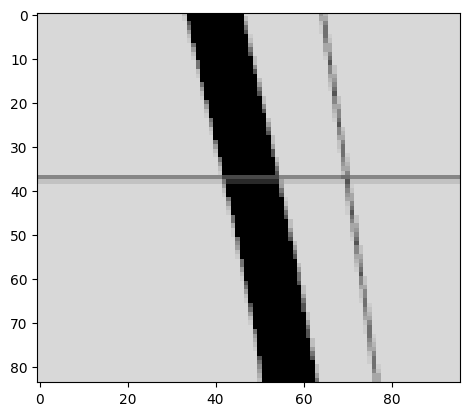

In [15]:
path = "../img/frame0.png"
img = cv2.imread(path)
plt.imshow(img)

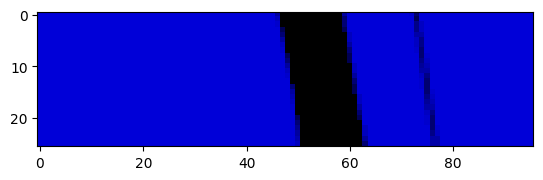

In [48]:
h = img.shape[0]
roi = img[int(h*0.7):h, :]

roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV_FULL)
plt.imshow(roi)

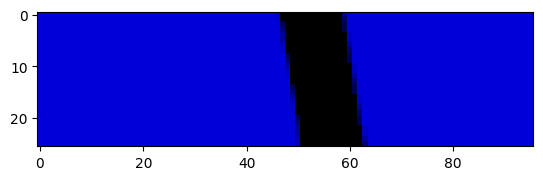

In [52]:
roi = cv2.medianBlur(roi, 13)
plt.imshow(roi)

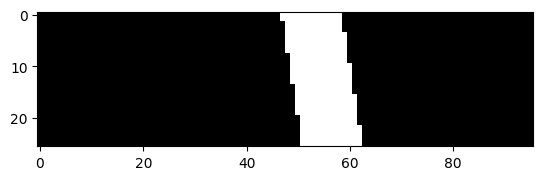

In [92]:
# alternativa 1
mask_a = cv2.inRange(roi, np.array([0, 0, 0]), np.array([180, 255, 50]))
plt.imshow(mask_a, cmap='gray')

In [101]:
contours, _ = cv2.findContours(mask_a, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
c = max(contours, key=cv2.contourArea)

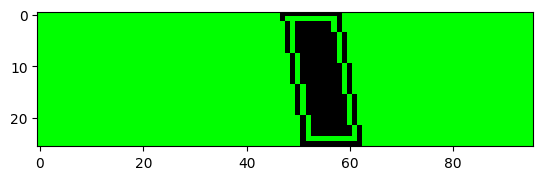

In [136]:
debug = roi.copy()
debug[mask < 100] = (0, 255, 0)
con_drawed = cv2.drawContours(debug, c, -1, (0, 255, 0), 1)
plt.imshow(con_drawed)

In [138]:
mom = cv2.moments(c)
display(mom)
cx, cy = int(mom["m10"]/mom["m00"]), int(mom["m01"]/mom["m00"])
cx, cy

{'m00': 199.0,
 'm10': 10881.5,
 'm01': 2495.5,
 'm20': 596510.3333333333,
 'm11': 137927.0833333333,
 'm02': 40047.666666666664,
 'm30': 32781832.75,
 'm21': 7641344.166666667,
 'm12': 2226823.5,
 'm03': 721791.75,
 'mu20': 1500.070770519087,
 'mu11': 1470.8860971523973,
 'mu02': 8753.595058626459,
 'mu30': 57.7130880728364,
 'mu21': 125.92060807024245,
 'mu12': 90.44801899016602,
 'mu03': 42.277114214375615,
 'nu20': 0.037879618457086615,
 'nu11': 0.037142650366212906,
 'nu02': 0.22104479832899318,
 'nu30': 0.00010330982403935377,
 'nu21': 0.00022540529881623155,
 'nu12': 0.00016190727681716558,
 'nu03': 7.567852243266996e-05}

(54, 12)

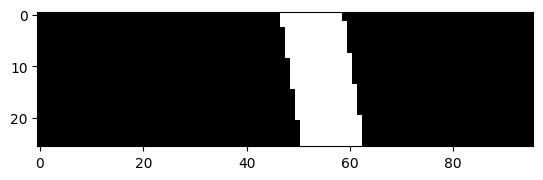

In [67]:
# alternativa 2
gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

ret, mask_b = cv2.threshold(gray_roi, 0, 65, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
plt.imshow(thresh, cmap='gray')